## Neural network for image classification

- Notebook for building a neural network to classify images using TensorFlow and Keras.
- Approach taken in this notebook will use all pixels of the image as input to the model, which is a common approach for image classification tasks.
- The model will be a simple feedforward neural network with few hidden layers, which is a good starting point for image classification tasks and understanding the basics of neural networks.

Note* - use google colab for this notebook as it has CPU/GPU support which can speed up the training process.

### Import required libraries and modules

In [1]:
import cv2
import numpy as np
import os
import zipfile
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from google.colab.patches import cv2_imshow

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from keras.models import save_model

In [2]:
tf.__version__

'2.20.0'

### Extracting pixels from images
- To use all pixels of the image as input to the model, we need to extract the pixel values from the images and convert them into a format that can be fed into the neural network.
- We can use the `cv2` library to read the images and extract the pixel values. The pixel values will be in the form of a 3D array (height x width x channels) for color images, and we can flatten this array into a 1D array to use as input to the model.
- For example, if we have an image of size 224x224 pixels with 3 color channels (RGB), the input to the model will be a 1D array of size 150528 (224 x 224 x 3).
- We can also normalize the pixel values to be between 0 and 1 by dividing the pixel values by 255, which can help improve the training process of the neural network.

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = '/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/homer_bart_1.zip'
zip_object = zipfile.ZipFile(file = path, mode = 'r')
zip_object.extractall('./')
zip_object.close()

In [5]:
directory = '/content/homer_bart_1'
files = [os.path.join(directory, f) for f in sorted(os.listdir(directory))]
print(files, '\n')
print(" type(files):", type(files))

['/content/homer_bart_1/.DS_Store', '/content/homer_bart_1/bart1.bmp', '/content/homer_bart_1/bart10.bmp', '/content/homer_bart_1/bart100.bmp', '/content/homer_bart_1/bart101.bmp', '/content/homer_bart_1/bart102.bmp', '/content/homer_bart_1/bart103.bmp', '/content/homer_bart_1/bart104.bmp', '/content/homer_bart_1/bart105.bmp', '/content/homer_bart_1/bart106.bmp', '/content/homer_bart_1/bart108.bmp', '/content/homer_bart_1/bart109.bmp', '/content/homer_bart_1/bart11.bmp', '/content/homer_bart_1/bart110.bmp', '/content/homer_bart_1/bart111.bmp', '/content/homer_bart_1/bart112.bmp', '/content/homer_bart_1/bart113.bmp', '/content/homer_bart_1/bart114.bmp', '/content/homer_bart_1/bart115.bmp', '/content/homer_bart_1/bart116.bmp', '/content/homer_bart_1/bart117.bmp', '/content/homer_bart_1/bart118.bmp', '/content/homer_bart_1/bart119.bmp', '/content/homer_bart_1/bart12.bmp', '/content/homer_bart_1/bart120.bmp', '/content/homer_bart_1/bart121.bmp', '/content/homer_bart_1/bart122.bmp', '/conte

In [ ]:
# resize all images to 128x128, and store them in a list along with their corresponding class labels (0 for Homer, 1 for Bart).
height, width = 128, 128 
# create empty lists to store the images and class labels, and a dictionary to map class names to labels
images = []
classes = []

In [ ]:
print("Total number of pixels in an image (including RGB channels): " + str(128 * 128 * 3))
print("Total number of pixels in an image (grayscale): " + str(128 * 128))

(49152, 16384)

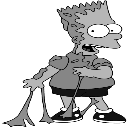

(16384,)
0


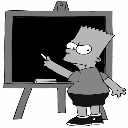

(16384,)
0


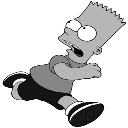

(16384,)
0


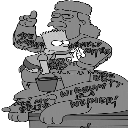

(16384,)
0


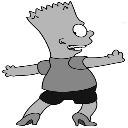

(16384,)
0


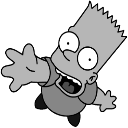

(16384,)
0


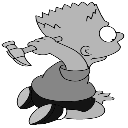

(16384,)
0


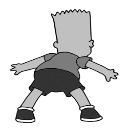

(16384,)
0


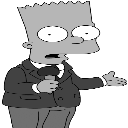

(16384,)
0


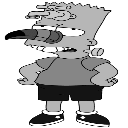

(16384,)
0


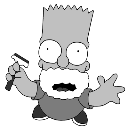

(16384,)
0


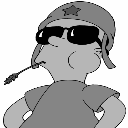

(16384,)
0


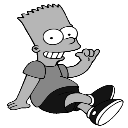

(16384,)
0


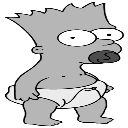

(16384,)
0


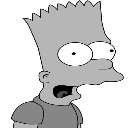

(16384,)
0


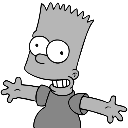

(16384,)
0


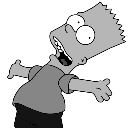

(16384,)
0


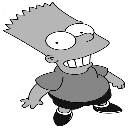

(16384,)
0


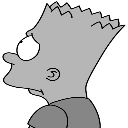

(16384,)
0


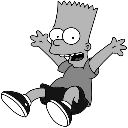

(16384,)
0


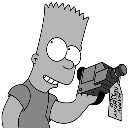

(16384,)
0


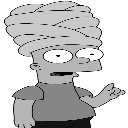

(16384,)
0


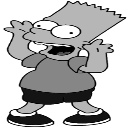

(16384,)
0


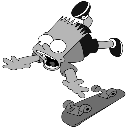

(16384,)
0


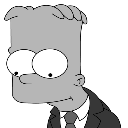

(16384,)
0


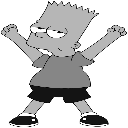

(16384,)
0


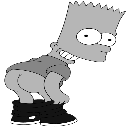

(16384,)
0


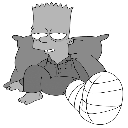

(16384,)
0


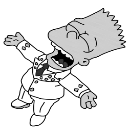

(16384,)
0


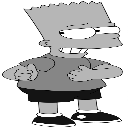

(16384,)
0


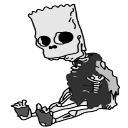

(16384,)
0


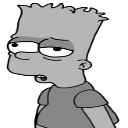

(16384,)
0


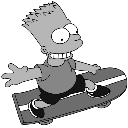

(16384,)
0


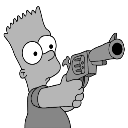

(16384,)
0


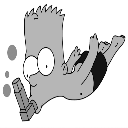

(16384,)
0


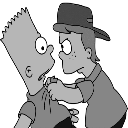

(16384,)
0


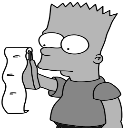

(16384,)
0


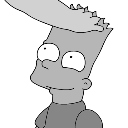

(16384,)
0


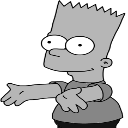

(16384,)
0


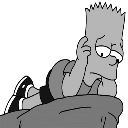

(16384,)
0


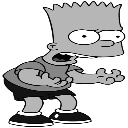

(16384,)
0


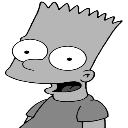

(16384,)
0


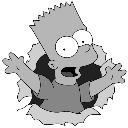

(16384,)
0


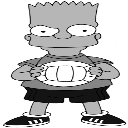

(16384,)
0


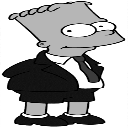

(16384,)
0


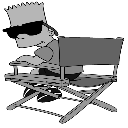

(16384,)
0


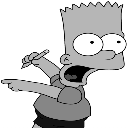

(16384,)
0


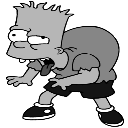

(16384,)
0


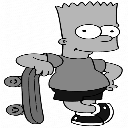

(16384,)
0


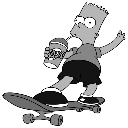

(16384,)
0


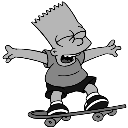

(16384,)
0


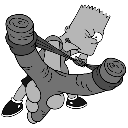

(16384,)
0


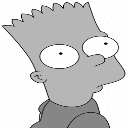

(16384,)
0


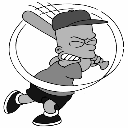

(16384,)
0


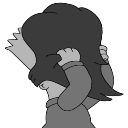

(16384,)
0


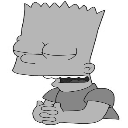

(16384,)
0


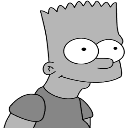

(16384,)
0


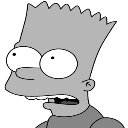

(16384,)
0


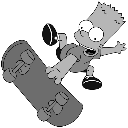

(16384,)
0


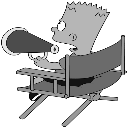

(16384,)
0


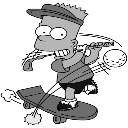

(16384,)
0


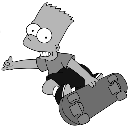

(16384,)
0


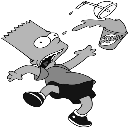

(16384,)
0


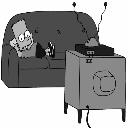

(16384,)
0


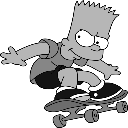

(16384,)
0


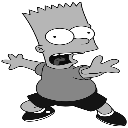

(16384,)
0


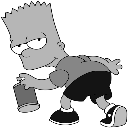

(16384,)
0


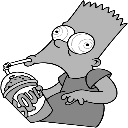

(16384,)
0


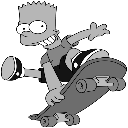

(16384,)
0


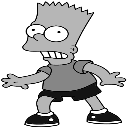

(16384,)
0


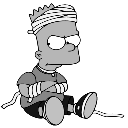

(16384,)
0


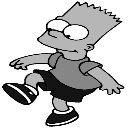

(16384,)
0


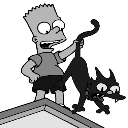

(16384,)
0


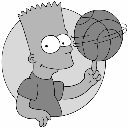

(16384,)
0


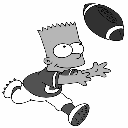

(16384,)
0


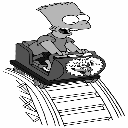

(16384,)
0


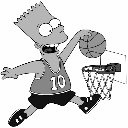

(16384,)
0


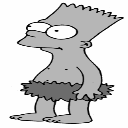

(16384,)
0


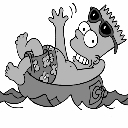

(16384,)
0


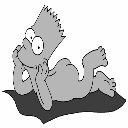

(16384,)
0


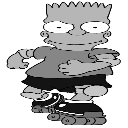

(16384,)
0


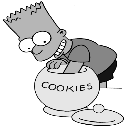

(16384,)
0


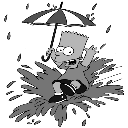

(16384,)
0


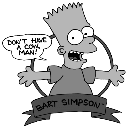

(16384,)
0


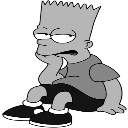

(16384,)
0


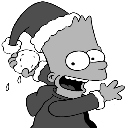

(16384,)
0


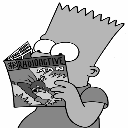

(16384,)
0


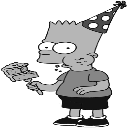

(16384,)
0


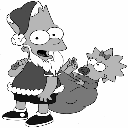

(16384,)
0


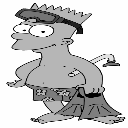

(16384,)
0


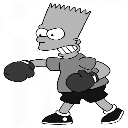

(16384,)
0


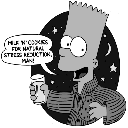

(16384,)
0


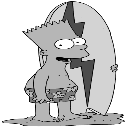

(16384,)
0


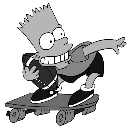

(16384,)
0


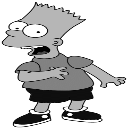

(16384,)
0


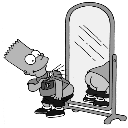

(16384,)
0


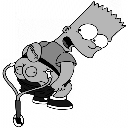

(16384,)
0


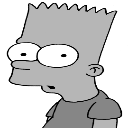

(16384,)
0


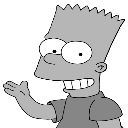

(16384,)
0


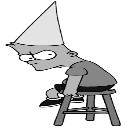

(16384,)
0


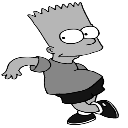

(16384,)
0


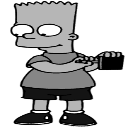

(16384,)
0


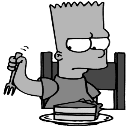

(16384,)
0


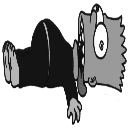

(16384,)
0


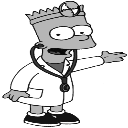

(16384,)
0


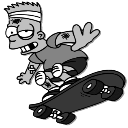

(16384,)
0


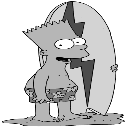

(16384,)
0


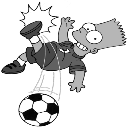

(16384,)
0


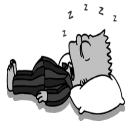

(16384,)
0


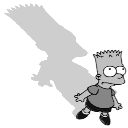

(16384,)
0


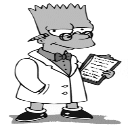

(16384,)
0


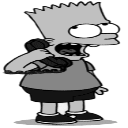

(16384,)
0


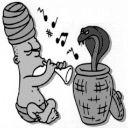

(16384,)
0


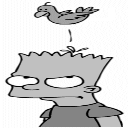

(16384,)
0


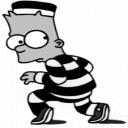

(16384,)
0


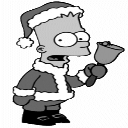

(16384,)
0


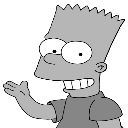

(16384,)
0


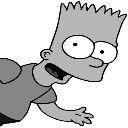

(16384,)
0


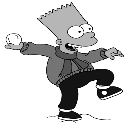

(16384,)
0


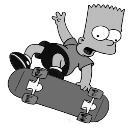

(16384,)
0


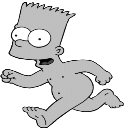

(16384,)
0


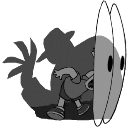

(16384,)
0


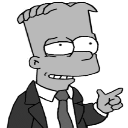

(16384,)
0


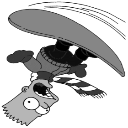

(16384,)
0


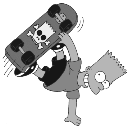

(16384,)
0


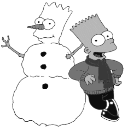

(16384,)
0


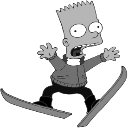

(16384,)
0


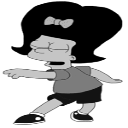

(16384,)
0


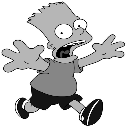

(16384,)
0


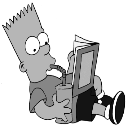

(16384,)
0


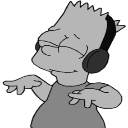

(16384,)
0


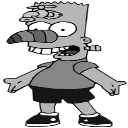

(16384,)
0


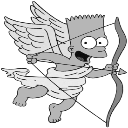

(16384,)
0


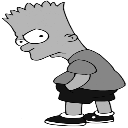

(16384,)
0


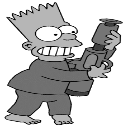

(16384,)
0


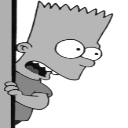

(16384,)
0


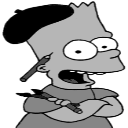

(16384,)
0


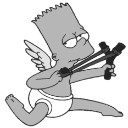

(16384,)
0


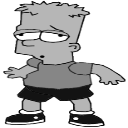

(16384,)
0


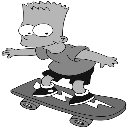

(16384,)
0


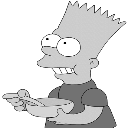

(16384,)
0


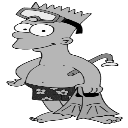

(16384,)
0


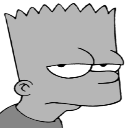

(16384,)
0


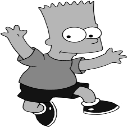

(16384,)
0


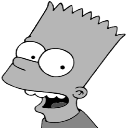

(16384,)
0


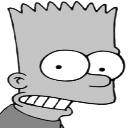

(16384,)
0


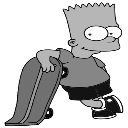

(16384,)
0


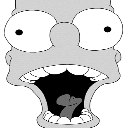

(16384,)
0


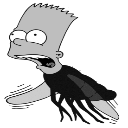

(16384,)
0


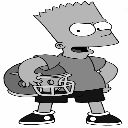

(16384,)
0


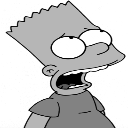

(16384,)
0


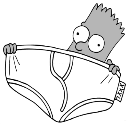

(16384,)
0


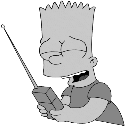

(16384,)
0


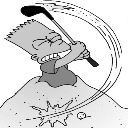

(16384,)
0


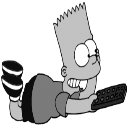

(16384,)
0


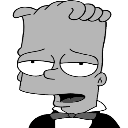

(16384,)
0


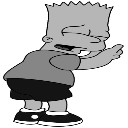

(16384,)
0


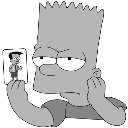

(16384,)
0


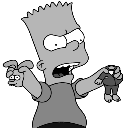

(16384,)
0


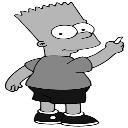

(16384,)
0


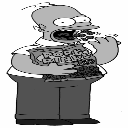

(16384,)
1


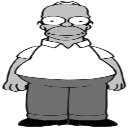

(16384,)
1


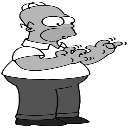

(16384,)
1


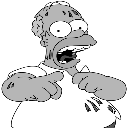

(16384,)
1


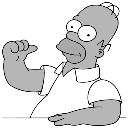

(16384,)
1


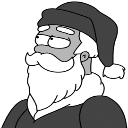

(16384,)
1


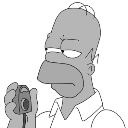

(16384,)
1


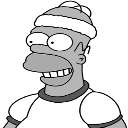

(16384,)
1


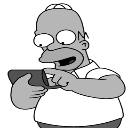

(16384,)
1


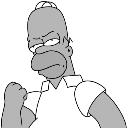

(16384,)
1


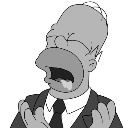

(16384,)
1


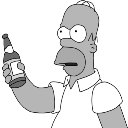

(16384,)
1


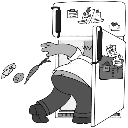

(16384,)
1


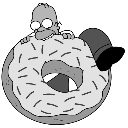

(16384,)
1


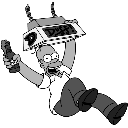

(16384,)
1


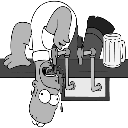

(16384,)
1


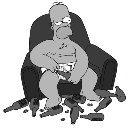

(16384,)
1


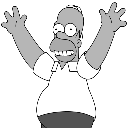

(16384,)
1


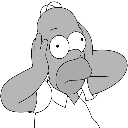

(16384,)
1


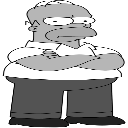

(16384,)
1


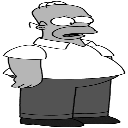

(16384,)
1


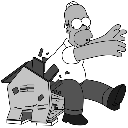

(16384,)
1


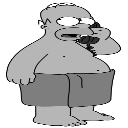

(16384,)
1


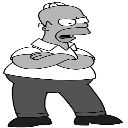

(16384,)
1


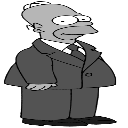

(16384,)
1


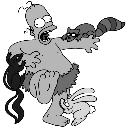

(16384,)
1


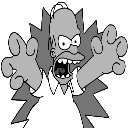

(16384,)
1


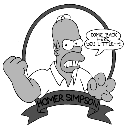

(16384,)
1


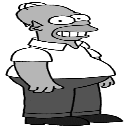

(16384,)
1


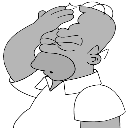

(16384,)
1


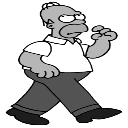

(16384,)
1


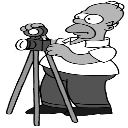

(16384,)
1


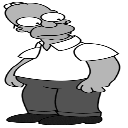

(16384,)
1


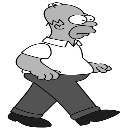

(16384,)
1


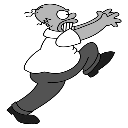

(16384,)
1


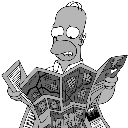

(16384,)
1


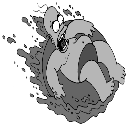

(16384,)
1


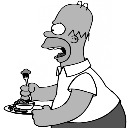

(16384,)
1


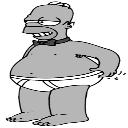

(16384,)
1


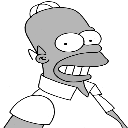

(16384,)
1


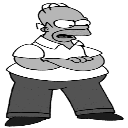

(16384,)
1


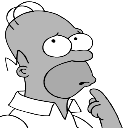

(16384,)
1


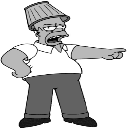

(16384,)
1


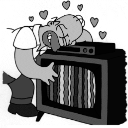

(16384,)
1


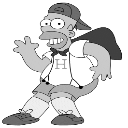

(16384,)
1


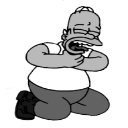

(16384,)
1


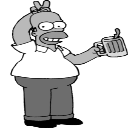

(16384,)
1


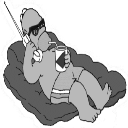

(16384,)
1


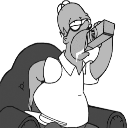

(16384,)
1


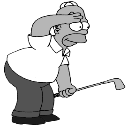

(16384,)
1


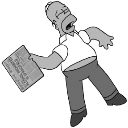

(16384,)
1


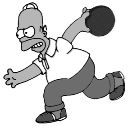

(16384,)
1


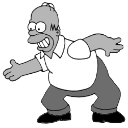

(16384,)
1


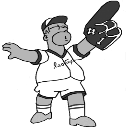

(16384,)
1


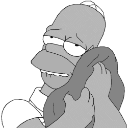

(16384,)
1


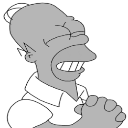

(16384,)
1


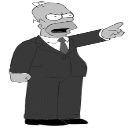

(16384,)
1


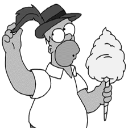

(16384,)
1


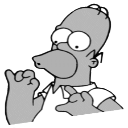

(16384,)
1


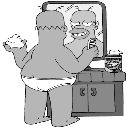

(16384,)
1


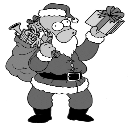

(16384,)
1


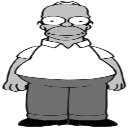

(16384,)
1


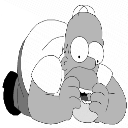

(16384,)
1


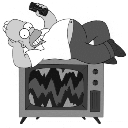

(16384,)
1


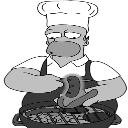

(16384,)
1


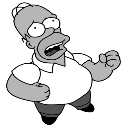

(16384,)
1


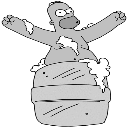

(16384,)
1


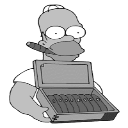

(16384,)
1


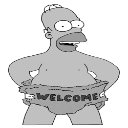

(16384,)
1


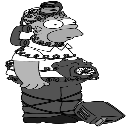

(16384,)
1


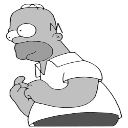

(16384,)
1


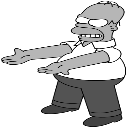

(16384,)
1


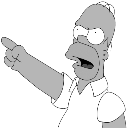

(16384,)
1


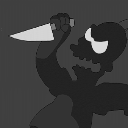

(16384,)
1


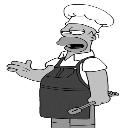

(16384,)
1


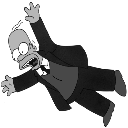

(16384,)
1


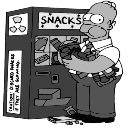

(16384,)
1


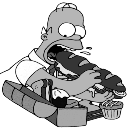

(16384,)
1


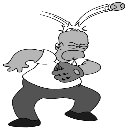

(16384,)
1


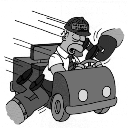

(16384,)
1


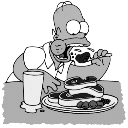

(16384,)
1


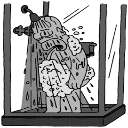

(16384,)
1


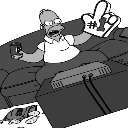

(16384,)
1


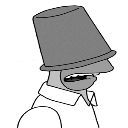

(16384,)
1


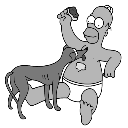

(16384,)
1


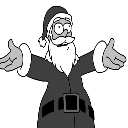

(16384,)
1


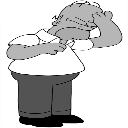

(16384,)
1


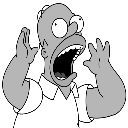

(16384,)
1


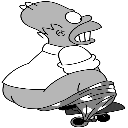

(16384,)
1


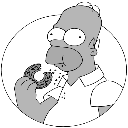

(16384,)
1


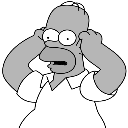

(16384,)
1


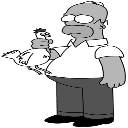

(16384,)
1


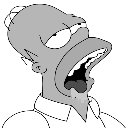

(16384,)
1


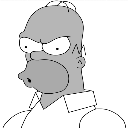

(16384,)
1


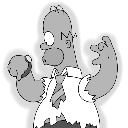

(16384,)
1


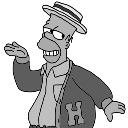

(16384,)
1


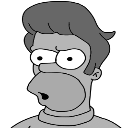

(16384,)
1


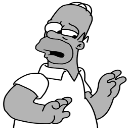

(16384,)
1


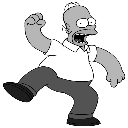

(16384,)
1


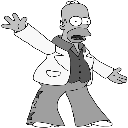

(16384,)
1


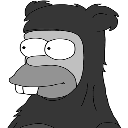

(16384,)
1


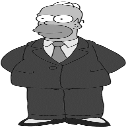

(16384,)
1


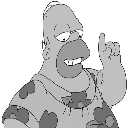

(16384,)
1


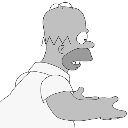

(16384,)
1


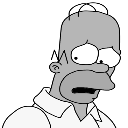

(16384,)
1


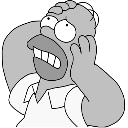

(16384,)
1


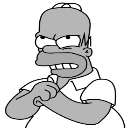

(16384,)
1


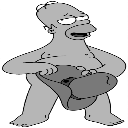

(16384,)
1


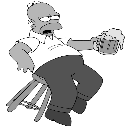

(16384,)
1


In [ ]:
# loop through the image files, read and preprocess each image, and store the preprocessed images and class labels in the respective lists. 
# The class label is determined based on the filename, where images starting with 'b' are labeled as 0 (Homer) and the rest are labeled as 1 (Bart). 
# The images are resized to 128x128 pixels and converted to grayscale before being flattened into a 1D array and stored in the 'images' list. 
# The corresponding class labels are stored in the 'classes' list. 

for image_path in files:
  #print(image_path)
  try:
    # read the image and get its dimensions (height and width)
    image = cv2.imread(image_path)
    (H, W) = image.shape[:2]
  except:
    continue

  # resize the image to 128x128 pixels and convert it to grayscale, then display the preprocessed image and print its shape and corresponding class label. 
  image = cv2.resize(image, (width, height))
  image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  
  cv2_imshow(image)
  
  # flatten the image into a 1D array and print its shape, then append the flattened image to the 'images' list.
  image = image.ravel()
  print(image.shape)

  images.append(image)

  # extract the class label from the filename and print it, then append the class label to the 'classes' list. The class label is determined based on the filename, where images starting with 'b' are labeled as 0 (Homer) and the rest are labeled as 1 (Bart).
  image_name = os.path.basename(os.path.normpath(image_path))
  if image_name.startswith('b'):
    class_name = 0
  else:
    class_name = 1

  # append the class label to the 'classes' list and print it. The class label is determined based on the filename, where images starting with 'b' are labeled as 0 (Homer) and the rest are labeled as 1 (Bart). 
  classes.append(class_name)
  print(class_name)

In [ ]:
images

[array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 128, 123, 124], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], dtype=uint8),
 array([255, 2

In [12]:
print(classes)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [13]:
type(images), type(classes)

(list, list)

In [14]:
X = np.asarray(images)
y = np.asarray(classes)
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [15]:
X.shape # 128 * 128

(269, 16384)

In [16]:
y.shape

(269,)

In [17]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

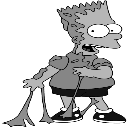

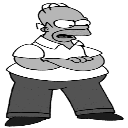

In [18]:
X[0].reshape(width, height).shape
cv2_imshow(X[0].reshape(width, height))
cv2_imshow(X[200].reshape(width, height))

<Axes: ylabel='count'>

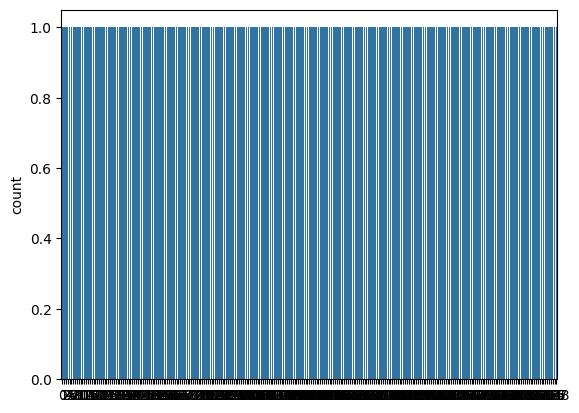

In [ ]:
sns.countplot(y)

In [ ]:
# check the unique class labels and their counts in the 'y' array, which contains the class labels for the images. This will help us understand the distribution of classes in our dataset.
np.unique(y, return_counts=True)

(array([0, 1]), array([160, 109]))

### Normalizing the data

In [23]:
X[0].max(), X[0].min()

(np.uint8(255), np.uint8(0))

In [ ]:
# normalize the pixel values in the 'X' array to be between 0 and 1 using MinMaxScaler. This is done to improve the performance of machine learning algorithms by scaling the features to a common range. 
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [25]:
X[0].max(), X[0].min()

(np.float64(1.0000000000000002), np.float64(0.0))

In [26]:
X[1]

array([0.9947644 , 0.99479167, 0.99479167, ..., 0.99559471, 0.99595142,
       0.9950495 ])

### Train and test set

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [28]:
X_train.shape, y_train.shape
X_test.shape, y_test.shape

((54, 16384), (54,))

### Building and training the neural network

In [29]:
(16384 + 2) / 2

8193.0

In [ ]:
# create a sequential neural network model using Keras with three layers: an input layer with 8193 units and ReLU activation, a hidden layer with 8193 units and ReLU activation, and an output layer with 1 unit and sigmoid activation. The input shape of the first layer is set to (16384,) to match the number of pixels in the flattened grayscale images (128x128 = 16384). The output layer uses sigmoid activation because this is a binary classification problem (Homer vs Bart). 
# The architecture of the neural network is designed to reduce the dimensionality of the input data while still capturing important features for classification. The first layer reduces the input from 16384 features to 8193, and the second layer further reduces it to 8193 before the final output layer produces a binary classification output (0 or 1). The ReLU activation function is used in the hidden layers to introduce non-linearity, while the sigmoid activation function in the output layer is used to produce a probability-like output for binary classification.

# 16384 -> 8193 -> 8193 -> 1
network1 = tf.keras.models.Sequential()
network1.add(tf.keras.layers.Dense(input_shape=(16384,), units=8193, activation='relu'))
network1.add(tf.keras.layers.Dense(units=8193, activation = 'relu'))
network1.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
network1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# https://keras.io/api/optimizers/
# https://keras.io/api/losses/
network1.compile(optimizer='Adam', loss='binary_crossentropy', metrics = ['accuracy'])

In [33]:
history = network1.fit(X_train, y_train, epochs=50)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.5349 - loss: 153.6348
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.5581 - loss: 6.0098
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.5302 - loss: 2.9071
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.5023 - loss: 0.9279
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5488 - loss: 0.6916
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6419 - loss: 0.6374
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.6977 - loss: 0.6329
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6047 - loss: 0.6760
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.6512 - loss: 0.6512
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6791 - loss: 0.6372
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.5953 - loss: 0.6381
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.6512 - loss: 0.6090
Epoch 13/50

### Evaluating the neural network

In [34]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

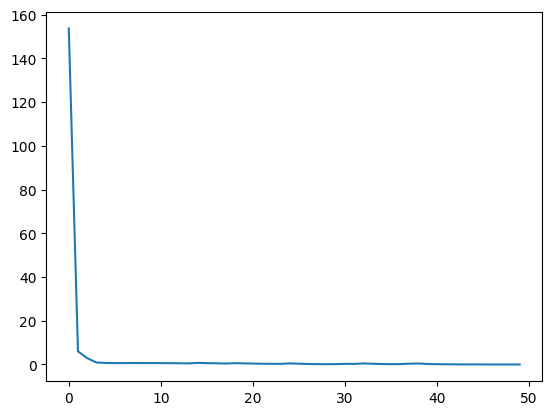

In [35]:
plt.plot(history.history['loss']);

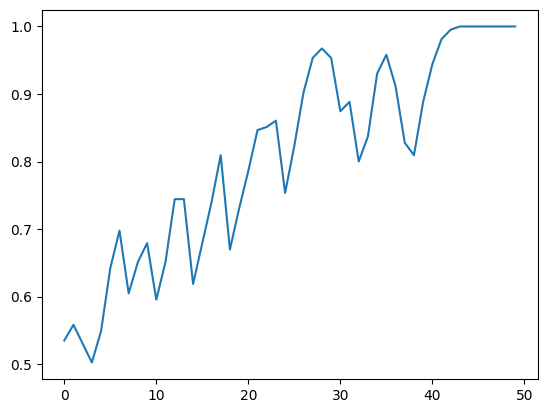

In [36]:
plt.plot(history.history['accuracy']);

In [37]:
X_test.shape

(54, 16384)

In [38]:
predictions = network1.predict(X_test)
predictions
# 0 False - Bart
# 1 True  - Homer

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step


array([[4.1565779e-03],
       [9.9974024e-01],
       [2.0136965e-02],
       [5.3127199e-02],
       [8.5117722e-01],
       [1.4928121e-02],
       [9.9937350e-01],
       [9.6234107e-01],
       [3.9934695e-01],
       [9.2875588e-01],
       [1.0744333e-01],
       [9.9999577e-01],
       [9.0971565e-01],
       [8.3402503e-01],
       [1.4122413e-01],
       [1.4641459e-02],
       [1.8829550e-01],
       [9.0055609e-01],
       [4.3743897e-02],
       [6.0928394e-03],
       [2.6730231e-03],
       [8.6470318e-01],
       [3.3643416e-03],
       [7.3959492e-02],
       [6.3533813e-02],
       [8.4813273e-01],
       [1.3662996e-02],
       [1.6145371e-02],
       [1.8032816e-01],
       [9.8313957e-01],
       [3.0889079e-01],
       [9.9957228e-01],
       [8.9623410e-01],
       [1.1279951e-03],
       [9.9996591e-01],
       [6.3298279e-03],
       [6.5018827e-01],
       [4.0023285e-03],
       [2.3901567e-01],
       [6.5469490e-03],
       [9.8253369e-01],
       [9.780245

In [39]:
predictions = (predictions > 0.5)
predictions

array([[False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False]])

In [40]:
y_test

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

In [41]:
accuracy_score(y_test, predictions)

0.7037037037037037

In [42]:
cm = confusion_matrix(y_test, predictions)
cm

array([[22,  6],
       [10, 16]])

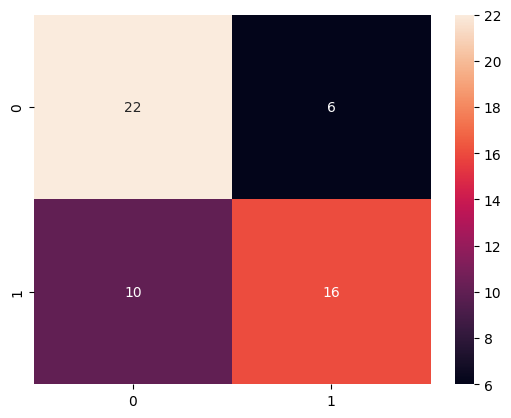

In [43]:
sns.heatmap(cm, annot=True);

In [44]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.69      0.79      0.73        28
           1       0.73      0.62      0.67        26

    accuracy                           0.70        54
   macro avg       0.71      0.70      0.70        54
weighted avg       0.71      0.70      0.70        54



### Saving and loading the network

In [45]:
model_json = network1.to_json()
with open('network1.json', 'w') as json_file:
  json_file.write(model_json)

In [46]:
network1_saved = save_model(network1, 'weights1.hdf5')

In [47]:
with open('network1.json') as json_file:
  json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 16384], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer", "optional": false}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 8193, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias

In [48]:
network1_loaded = tf.keras.models.model_from_json(json_saved_model)
network1_loaded.load_weights('/content/weights1.hdf5')
network1_loaded.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

### Testing / Verification - Classifying one single image

In [49]:
X_test[0].shape

(16384,)

In [51]:
test_image = X_test[34]
test_image = scaler.inverse_transform(test_image.reshape(1, -1))

In [52]:
test_image

array([[255., 255., 255., ..., 255., 255., 255.]])

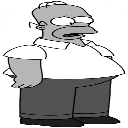

In [53]:
cv2_imshow(test_image.reshape(width, height))

In [54]:
network1_loaded.predict(test_image)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


np.float32(1.0)

In [55]:
if network1_loaded.predict(test_image)[0][0] < 0.5:
  print('Bart')
else:
  print('Homer')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Homer
